#**GDG TASK 3**

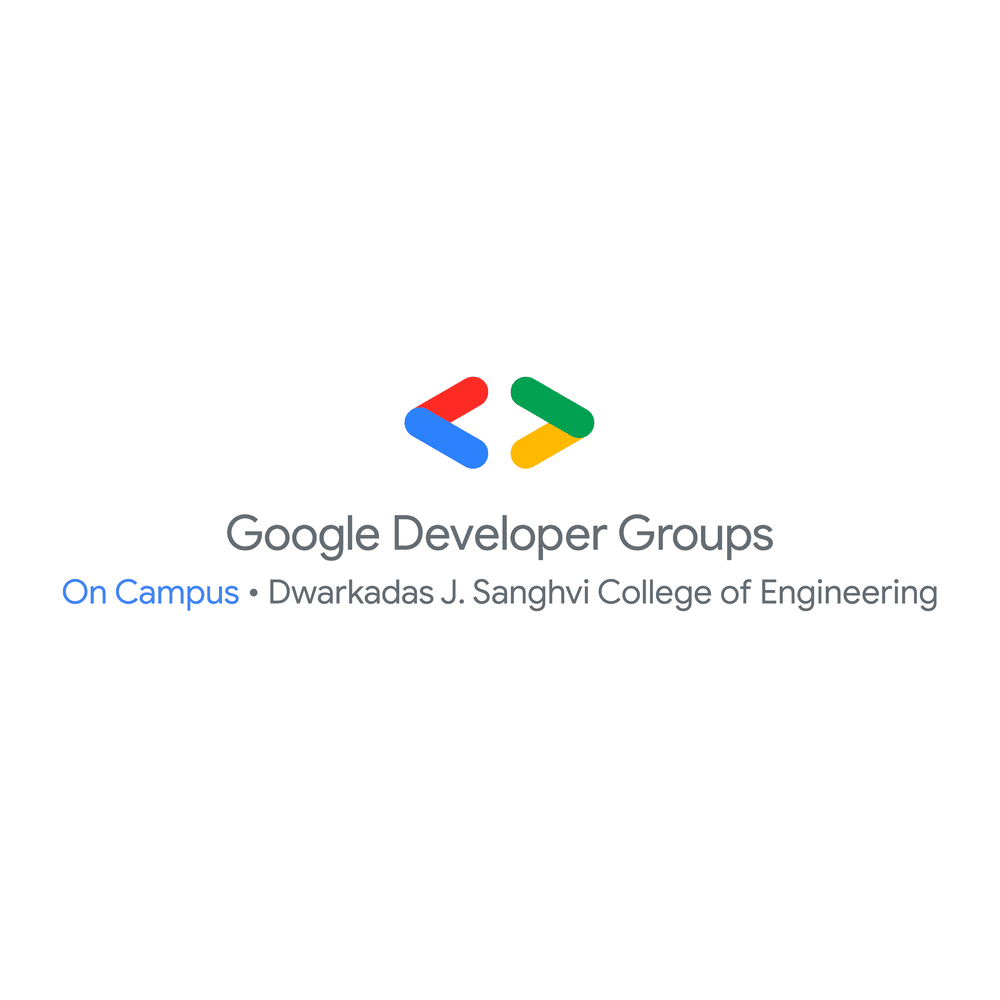

**Unsupervised Learning**

Clustering is an unsupervised learning technique used to group similar data points together. It's widely used in various applications like customer segmentation, anomaly detection, and more. In this task, we'll explore different clustering algorithms and visualize their results.

We will work with the **Samsung Human Activity Recognition dataset**. The data comes from the accelerometers and gyros of Samsung mobile phones, the type of activity of a person with a phone in his pocket is also known - whether he walked, stood, lay, sat or walked up or down the stairs.

We imagine that the type of activity is unknown to us (unlabelled), and we will try to cluster people purely on the basis of available features.

The dataset that will be used can be found here - [DATA](https://drive.google.com/drive/folders/1YiphBhq_SAN5JvCFrorv3pXIvQ22Jtat)

# Importing and Installing all the necessary libaries

In [117]:
!pip install yellowbrick -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from yellowbrick.cluster import KElbowVisualizer


from IPython.display import Image,display
from ipywidgets import interact
import os

import warnings
warnings.filterwarnings("ignore")

# Data Loading

Mention the path of dataset, 4 paths for the 4 different txt files.

In [118]:
# from google.colab import drive
# drive.mount('/content/drive')

### datasets link :- https://drive.google.com/drive/folders/19nsd8MvooWVsVzkNWxGtbMJheR7kzERt?usp=sharing

In [119]:
# Mention the path in the strings below
samsung_train_path = '/content/samsung_train.txt'
samsung_train_labels_path = '/content/samsung_train_labels.txt'
samsung_test_path = '/content/samsung_test.txt'
samsung_test_labels_path = '/content/samsung_test_labels.txt'

This time we will be using np.loadtxt() for reading our data. Code for the same has been given (do not modify), but we expect you to understand the working of it.

Ref.: https://www.geeksforgeeks.org/numpy-loadtxt-in-python/

In [120]:
# DO NOT MODIFY
X_train = np.loadtxt(samsung_train_path)
y_train = np.loadtxt(samsung_train_labels_path)#.astype(#fillhere#)

X_test = np.loadtxt(samsung_test_path)
y_test = np.loadtxt(samsung_test_labels_path)#.astype(#fillhere#)

Just to confirm that your data has been loaded properly, execute the below cell. You won't receive any error if everything is correct.

NOTE: If you get an Assertion error, then you probably did something wrong above.

In [121]:
# Checking dimensions
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

# **Pre-processing**

For clustering, we do not need a target vector, so we'll work with the combination of training and test samples. Merge *X_train* with *X_test*, and *y_train* with *y_test*.

Hint:
1. Merge X_train and X_test into X {use [np.vstack()](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html)}
2. Merge y_train and y_test into y {use [np.hstack()](https://numpy.org/doc/stable/reference/generated/numpy.hstack.html)}

In [122]:
# code
X = np.vstack((X_train,X_test))
y = np.hstack((y_train,y_test))
print(X.shape)
print(y.shape)


(10299, 561)
(10299,)


Using numpy, print the unique values of the labels of the target class (i.e. "y").

Ref.: https://www.geeksforgeeks.org/python-numpy-np-unique-method/

In [123]:
# code here
print(np.unique(y))


[1. 2. 3. 4. 5. 6.]


Store the size (or number) of unique values of the labels of the target class (i.e. "y") in a variable named n_classes.

In [124]:
# code
n_classes = len(np.unique(y))
print(n_classes)

6


In [125]:
activities = [
    "walking",
    "going up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "lying down"
]

Here the 6 labels (or classes) correspond to:
- 1 - walking
- 2 - going up the stairs
- 3 - going down the stairs
- 4 - sitting
- 5 - standing
- 6 - lying down

So we wish to create 6 clusters where each cluster can represent one of the above activities.

Scale the sample (i.e. X) using [`StandardScaler()`](https://www.digitalocean.com/community/tutorials/standardscaler-function-in-python)

In [126]:
# call library
# initialize an instance of StandardScaler()
#code
# use the above instance to fit_transform "X" and assign it into a new variable "X_scaled"
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Dimensionality Reduction using PCA**

Ref.: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [127]:
# Import PCA from sklearn.decomposition
from sklearn.decomposition import PCA
pca = PCA(n_components = 0.9 , random_state=17)
X_pca = np.array(pca.fit_transform(X_scaled))

Reduce the number of dimensions using PCA,

Hints:
1. Initialise instance of PCA and set *n_components* to 0.9 and *random_state* to 17.
2. Fit X_scaled over the PCA instance created
3. Transform X_scaled over the fitted PCA instance and store it in a variable named X_pca.

Theory: https://www.analyticsvidhya.com/blog/2022/07/principal-component-analysis-beginner-friendly/ and https://en.wikipedia.org/wiki/Principal_component_analysis

Theory + Implementation.: https://youtu.be/OFyyWcw2cyM (Jump to timestamp - 13:50 for PCA implementaion)

In [128]:
# code here
X_pca.shape

(10299, 65)

Let's check the shape of X_pca.

In [129]:
# code here

# Should print (10299, 65) if everything is correct.

Shape of X was (10299, 561) i.e 561 dimensions

Shape of X_pca is (10299, 65) i.e. 65 dimenisons

Hence we have successfully reduced dimensions using PCA.

# K-Means Clustering (Partition-Based Clustering)

K-means clustering is an essential partitioning algorithm used to categorize a dataset into 'k' distinct, non-overlapping clusters. Each data point is assigned to the cluster with the nearest mean or centroid, symbolizing the cluster's center. The primary goal of the algorithm is to minimize the sum of squared distances between data points and their respective cluster centroids.

For an in-depth exploration of K-means clustering, you can refer to this comprehensive article on Analytics Vidhya: [Comprehensive Guide to K-means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/).

For a deeper understanding of the mathematical underpinnings of K-means clustering, Wikipedia is a valuable resource. You can explore the Wikipedia page on K-means clustering for a detailed description: [K-means Clustering Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering). This will help you grasp the mathematical intricacies of the algorithm and its applications in machine learning.

### 2 Dimensional Visualization

In [130]:
## Perform K-Means clustering with interactive widget
def kmeans_clustering(num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('K-Means Clustering')
    plt.legend()
    plt.show()

low = 2
high = 6
scale = 1

interact(kmeans_clustering, num_clusters=(low,high,scale))

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.kmeans_clustering(num_clusters)>

### 3 Dimensional Visualization

In [131]:
## Perform K-Means clustering with interactive widget
def kmeans_3d_clustering(num_clusters):
    kmeans_3d = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_3d_labels = kmeans_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Kmeans Clustering (3D)')
    plt.show()

interact(kmeans_3d_clustering, num_clusters=(2, 6, 1))

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.kmeans_3d_clustering(num_clusters)>

### Elbow Point

The "elbow point" is a concept often used in the context of K-means clustering to help determine the optimal number of clusters (k) for a given dataset. It is a graphical method that can assist data analysts and machine learning practitioners in finding an appropriate value for k when applying K-means clustering.

The rationale behind the elbow point method is that as you increase the number of clusters (k), the sum of squared distances will generally decrease because data points will be closer to their respective cluster centroids. However, beyond a certain point, subdividing the data into more clusters doesn't provide significant improvements in reducing the sum of squared distances. The elbow point represents that optimal trade-off between the number of clusters and the compactness of each cluster.

It's important to note that the elbow point method is a heuristic and not a foolproof method for determining the ideal k value. In some cases, the elbow point may not be very pronounced, making it challenging to choose the best k. Additionally, the choice of k should also consider domain knowledge and the specific goals of your analysis.

Elbow Method to determine the number of clusters to be formed:


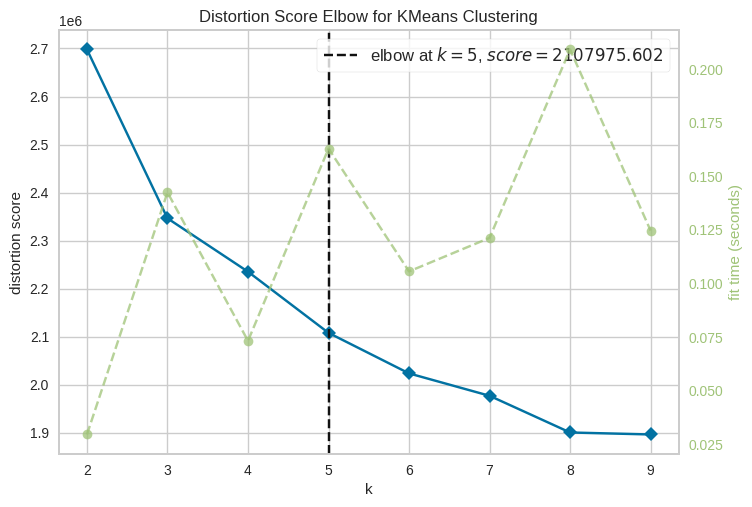

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [132]:
print('Elbow Method to determine the number of clusters to be formed:')

Elbow_M = KElbowVisualizer(KMeans(), k=(2, 10))
Elbow_M.fit(X_pca)
Elbow_M.show()

Similar to classification and regression metrics, we have some [clustering metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics) to evaluate performance.

We wll explore one of them: [adjusted_rand_index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)

In [133]:
from sklearn.metrics.cluster import adjusted_rand_score
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
# code to compute ARI for our KMeans clusters
print(f'ARI Score: {adjusted_rand_score(y,kmeans_labels)}')


ARI Score: 0.30359140125616413


# Agglomerative Clustering

It is a hierarchical clustering algorithm used in unsupervised machine learning and data analysis. It is a "bottom-up" or "agglomerative" approach to clustering, where individual data points are initially treated as their own clusters and then progressively merged into larger clusters based on a similarity or distance metric. The result is a tree-like structure called a dendrogram that represents the hierarchical relationships between clusters.

As always, You can find more detailed information about hierarchical clustering, including agglomerative clustering, in the Wikipedia article on "Hierarchical clustering" at the following link: [Hierarchical Clustering Wikipedia](https://en.wikipedia.org/wiki/Hierarchical_clustering). This is the best resource for hierarchical clustering and it is advisable to go through it twice if possible! :)

### 2 Dimensional Visualization

In [134]:
# Perform Agglomerative clustering with interactive widget
def agglomerative_clustering(num_clusters):
  agglomerative = AgglomerativeClustering(n_clusters=num_clusters)
  agglomerative_labels = agglomerative.fit_predict(X_pca)

  plt.figure(figsize=(8, 6))
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglomerative_labels, cmap='viridis', edgecolors='k')
  plt.xlabel('Feature 1 (Standardized)')
  plt.ylabel('Feature 2 (Standardized)')
  plt.title('Agglomerative Clustering')
  plt.legend()
  plt.show()

interact(agglomerative_clustering, num_clusters=(2,6,1)) # Fill here

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.agglomerative_clustering(num_clusters)>

### 3 Dimensional Visualization

In [135]:
# Perform Agglomerative clustering with interactive widget
def agglomerative_3d_clustering(num_clusters):
    agglomerative_3d = AgglomerativeClustering(n_clusters=num_clusters)
    agglomerative_3d_labels = agglomerative_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agglomerative_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('agglomerative Clustering (3D)')
    plt.show()

interact(agglomerative_3d_clustering, num_clusters=(2,6,1)) # Fill here

interactive(children=(IntSlider(value=4, description='num_clusters', max=6, min=2), Output()), _dom_classes=('…

<function __main__.agglomerative_3d_clustering(num_clusters)>

Text(0, 0.5, 'Euclidean dist')

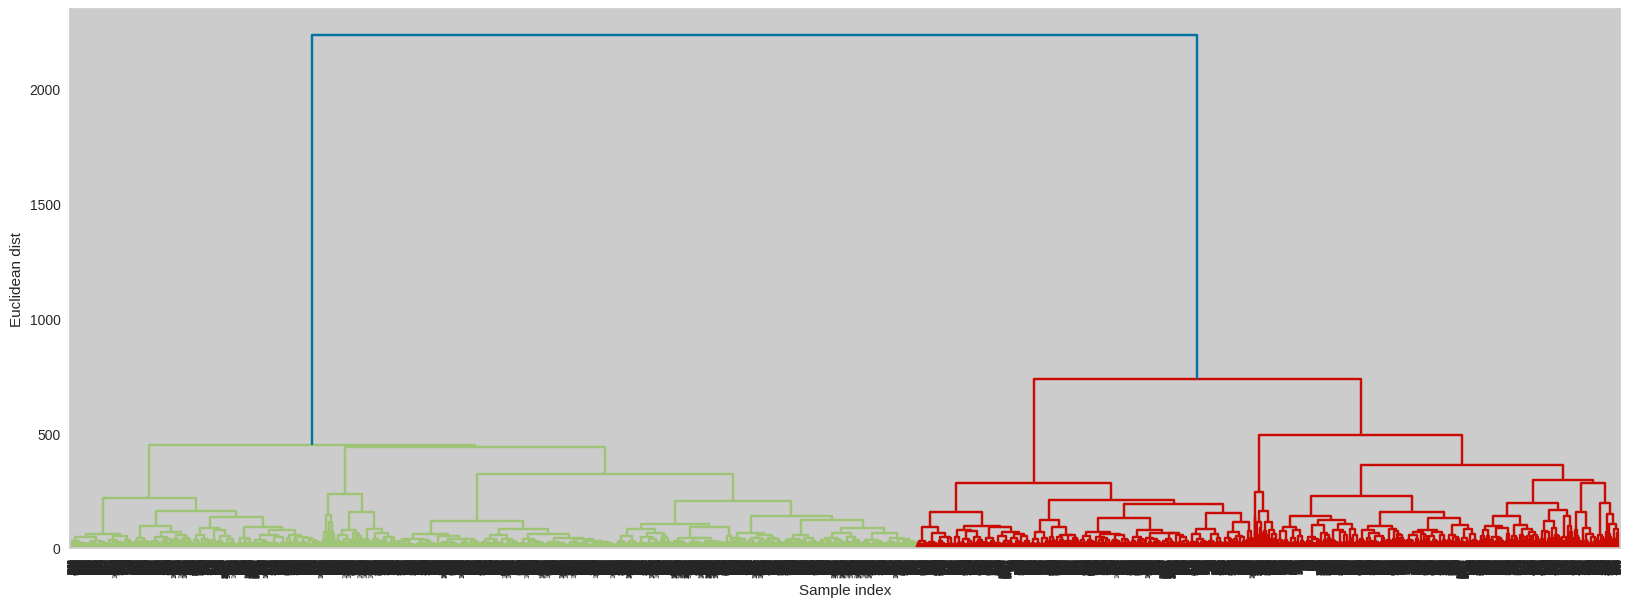

In [136]:
#go through the library of clusteval in order to draw and make dendrograms in your task!
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(20,7))
sc.dendrogram(sc.linkage(X_pca,method='ward'))
plt.xlabel('Sample index')
plt.ylabel('Euclidean dist')

# DBSCAN Clustering

DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, is a popular density-based clustering algorithm in unsupervised machine learning. It is particularly useful for discovering clusters of arbitrary shapes in datasets with varying levels of data density. DBSCAN is known for its ability to handle noise and outliers effectively.

As always, You can find additional information about how DBSCAN clustering works in the following article on Analytics Vidhya:

[How DBSCAN Clustering Works](https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/#:~:text=DBSCAN%20is%20a%20density%2Dbased,points%20into%20a%20single%20cluster.)

This article provides a detailed explanation of DBSCAN, including its underlying concepts, the role of epsilon (ε) and minimum points (MinPts), and practical examples of how to use DBSCAN for clustering. It's a valuable resource for gaining a deeper understanding of the algorithm with Wikipedia as the side resource.

### 2 Dimensional Visualization

In [137]:
# Perform DBSCAN clustering with interactive widget
def dbscan_clustering(eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('DBSCAN Clustering')
    plt.legend()
    plt.show()

interact(dbscan_clustering, eps=(0.1,3,1), min_samples=(2,6,1)) # Fill here

interactive(children=(FloatSlider(value=1.1, description='eps', max=3.0, min=0.1, step=1.0), IntSlider(value=4…

<function __main__.dbscan_clustering(eps, min_samples)>

### 3 Dimensional Visualization

In [138]:
# Perform DBSCAN clustering with interactive widget
def dbscan_3d_clustering(eps, min_samples):
    dbscan_3d = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_3d_labels = dbscan_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=dbscan_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('DBSCAN Clustering (3D)')
    plt.show()
interact(dbscan_3d_clustering, eps=(0.1, 3, 1), min_samples=(2, 6, 1)) # Fill here

interactive(children=(FloatSlider(value=1.1, description='eps', max=3.0, min=0.1, step=1.0), IntSlider(value=4…

<function __main__.dbscan_3d_clustering(eps, min_samples)>

# Mean Shift Clustering

It is a density-based clustering algorithm used in unsupervised machine learning and data analysis. Similar to DBSCAN, Mean Shift is capable of discovering clusters with arbitrary shapes and sizes in a dataset. It is particularly useful for applications where the number of clusters is not known in advance and when clusters have varying densities.

For more hands-on information about the Mean Shift clustering algorithm, you can refer to this tutorial on Analytics India Magazine:

[Hands-On Tutorial on Mean Shift Clustering Algorithm](https://analyticsindiamag.com/hands-on-tutorial-on-mean-shift-clustering-algorithm/)

This tutorial provides practical insights into how to implement and use Mean Shift clustering, making it a valuable resource for those looking to apply this clustering technique to real-world data analysis and machine learning tasks especially in the sector of Image Segmentation.

### 2 Dimensional Visualization

In [139]:
# Perform Mean Shift clustering with interactive widget
def meanshift_clustering(n_band):
    mean_shift = MeanShift(bandwidth=n_band)
    mean_shift_labels = mean_shift.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mean_shift_labels, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('Mean Shift Clustering')
    plt.legend()
    plt.show()

interact(meanshift_clustering, n_band=(2,6,1)) # Fill here

interactive(children=(IntSlider(value=4, description='n_band', max=6, min=2), Output()), _dom_classes=('widget…

<function __main__.meanshift_clustering(n_band)>

### 3 Dimensional Visualization

In [140]:
# Perform Mean Shift clustering with interactive widget
def meanshift_clustering(n_band):
    meanshift_3d = MeanShift(bandwidth=n_band)
    meanshift_3d_labels = meanshift_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=meanshift_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Mean Shift Clustering (3D)')
    plt.show()

interact(meanshift_clustering, n_band=(2,6,1))

interactive(children=(IntSlider(value=4, description='n_band', max=6, min=2), Output()), _dom_classes=('widget…

<function __main__.meanshift_clustering(n_band)>

***Congratulations! You have explored various clustering algorithms. Each algorithm has its own advantages and use cases. Remember, choosing the right algorithm and the right number of clusters is crucial. Feel free to experiment with different datasets and parameters to gain a better understanding.***

# **Compulsory**

You can research and create a short blog on the topic of **Spectral Clustering Algortihm and Divisive Clustering**.



# Spectral clustering
Spectral clustering treats data as a graph instead of a plain set of points in Euclidean space. Each data point is a node, and edges encode how similar or “close” two points are. The key idea is to use eigenvalues and eigenvectors of a matrix derived from this graph to find clusters.
# ​At a high level:
**​Build a similarity graph:** Connect points that are close (for example, using k‑nearest neighbors or an ε-neighborhood) and assign edge weights based on a similarity function, such as a Gaussian kernel.

**Construct the Laplacian:**
From the similarity matrix W and degree matrix D, form a graph Laplacian like L=D−W or its normalized variants.

**Compute eigenvectors:** Take the first k eigenvectors of
L to embed points into a low‑dimensional space where cluster structure becomes clearer.

**Run a standard algorithm:** Apply k‑means or another simple clustering method in this spectral space to obtain the final clusters.

Because it operates on the structure of a graph, spectral clustering can capture complex, non‑convex shapes and patterns that defeat classical k‑means.
​

**Why spectral clustering matters**
Spectral clustering is widely used when relationships matter more than raw coordinates.
​

**Common use cases include:**
Image segmentation,Community detection,Customer or document segmentation.
​

# Divisive clustering: top‑down hierarchy
Divisive clustering is a hierarchical clustering strategy that starts with all data in a single cluster and recursively splits it into smaller clusters. This is the opposite of agglomerative clustering, which starts from singletons and merges them.
​

**A generic divisive clustering procedure looks like this:**
**​Start:** Place all points in one cluster.

**Select a cluster to split:** Often the cluster with the highest within‑cluster dissimilarity or largest sum of squared errors (SSE) is chosen.

**Split the cluster:** Use a flat method (e.g., k‑means with
k=2) or a heuristic that maximizes separation between the two resulting subclusters.

**Repeat:** Continue choosing clusters to split until a stopping condition is met, such as a desired number of clusters or minimal dissimilarity gain.

The process produces a dendrogram that captures nested structure: once a cluster is split, its members never re‑merge, which encodes a clear, irreversible top‑down hierarchy.
​

**When to use divisive clustering**
Divisive clustering shines when the goal is not just to assign labels but also to understand hierarchical relationships among groups.
​

# It is particularly useful when:

A top‑down story is natural: For example, starting from “Electronics” and subdividing into “Computers” and “Mobiles,” then further into “Laptops,” “Smartphones,” and “Feature Phones.”
​

Interpretability is key: Analysts can read the tree to see how broad categories refine into more specific ones.

​



we will be exploring another ML Models like Decision Tree, Random Forest and Naive Bayes. We will also learn hyperparameter tuning using ensemble techniques (Bagging & Boosting) and Decision Tree Pruning.

**This Task has various theory questions to be answered here and there. Don't miss out on those, as they will make you'll conceptually stronger, and give a better understanding.**

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

# Decision Tree Classifier

* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

### separate datset for this task.

Load the titanic dataset in a pandas dataframe (download dataset from https://www.kaggle.com/c/titanic/data and store it in the "Synapse" folder initially created for the interview tasks) Note that you have to download the train and test csv files seperately

<b>Read the train.csv using pandas and show the dataframe</b>

In [170]:
#code here
df_train = pd.read_csv('/content/train.csv')
X_train = df_train.drop(columns=['Survived'])
y_train = df_train['Survived']
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Visualizing hidden Details

* print the name column of the data
* notice that the word after the first comma encapsulates the title of the person (Mr., Mrs, etc)
* extract the title using regular expression (help given below in the code)
* store the title in a new column in the dataframe. Name the column : Title

In [171]:
X_train['Name'].head()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [172]:
# try researching about regex
X_train['Title'] = X_train['Name'].str.extract(r',\s*([^\.]+)\.')
X_train['Title'] = X_train['Title'].str.strip()
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [173]:
X_train.loc[X_train['Title']==np.nan]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title



```
# This is formatted as code
```

### Removing unnecessary columns
*   The columns PassengerId and Ticket play no logical role in being related to the survival of a passenger. Hence we will remove them.
*   We will also remove the Name column as we have done feature extraction and obtained titles instead. (test set might have extra titles which are not in the train set. Think about how we would consider them. This however doesn't affect task 1's objective)

In [174]:
X_test = pd.read_csv('/content/test.csv')
X_test['Title'] = X_test['Name'].str.extract(r',\s*([^\.]+)\.')
X_test['Title'] = X_test['Title'].str.strip()

In [175]:
#write code here (PassengerId, Ticket, Name)
X_train = X_train.drop(columns=['PassengerId','Ticket','Name'])
X_test = X_test.drop(columns=['PassengerId','Ticket','Name'])

### Nan analysis
*   write code to find the percentage of Nans in each column and visualize it in a tabular format
*   remove any column having more than 50% Nans as they would be of no use

In [176]:
# likho code and tree null values properly
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,687
Embarked,2
Title,0


In [177]:
# Age almost 20 % null values whereas Cabin has more than 60% null values , so drop Cabin , impute Age in both test & train sets
X_train = X_train.drop(columns=['Cabin'])
X_test = X_test.drop(columns=['Cabin'])

In [178]:
# calculating median using just train set and not test set , to avoid leakage
age_median = X_train['Age'].median()
X_train['Age'].fillna(age_median, inplace=True)
X_test['Age'].fillna(age_median, inplace=True)

In [179]:
# embarked has just 2 null though imputing it
embarked_mode = X_train['Embarked'].mode()[0]
X_train['Embarked'].fillna(embarked_mode, inplace=True)
X_test['Embarked'].fillna(embarked_mode, inplace=True)

In [180]:
fare_median = X_train.loc[X_train['Fare'] > 0, 'Fare'].median()

X_train['Fare'] = X_train['Fare'].replace(0, fare_median)
X_train['Fare'].fillna(fare_median, inplace=True)

X_test['Fare'] = X_test['Fare'].replace(0, fare_median)
X_test['Fare'].fillna(fare_median, inplace=True)

In [181]:
print(X_train.head())
print(X_test.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title
0       3    male  22.0      1      0   7.2500        S    Mr
1       1  female  38.0      1      0  71.2833        C   Mrs
2       3  female  26.0      0      0   7.9250        S  Miss
3       1  female  35.0      1      0  53.1000        S   Mrs
4       3    male  35.0      0      0   8.0500        S    Mr
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title
0       3    male  34.5      0      0   7.8292        Q    Mr
1       3  female  47.0      1      0   7.0000        S   Mrs
2       2    male  62.0      0      0   9.6875        Q    Mr
3       3    male  27.0      0      0   8.6625        S    Mr
4       3  female  22.0      1      1  12.2875        S   Mrs


### Adding features to the dataset
*   Read the kaggle link (titanic dataset) provided above and see what the two columns SibSP and Parch signify
*   Using that create a new column called **Family_members**
*   Fill it with the sum of SibSP and Parch

In [182]:
#write code here
X_train['Family_members'] = X_train['SibSp']+X_train['Parch']
X_test['Family_members'] = X_test['SibSp']+X_test['Parch']

In [183]:
print(X_train.head())
print(X_test.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title  Family_members
0       3    male  22.0      1      0   7.2500        S    Mr               1
1       1  female  38.0      1      0  71.2833        C   Mrs               1
2       3  female  26.0      0      0   7.9250        S  Miss               0
3       1  female  35.0      1      0  53.1000        S   Mrs               1
4       3    male  35.0      0      0   8.0500        S    Mr               0
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked Title  Family_members
0       3    male  34.5      0      0   7.8292        Q    Mr               0
1       3  female  47.0      1      0   7.0000        S   Mrs               1
2       2    male  62.0      0      0   9.6875        Q    Mr               0
3       3    male  27.0      0      0   8.6625        S    Mr               0
4       3  female  22.0      1      1  12.2875        S   Mrs               2


**Pre Processing**

In [184]:
#ab ana chahiye after task 2
# observe! , too many categories in "Title", need to reduce them!!
X_train['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [185]:
title_map = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Master': 'Master',
    'Mlle': 'Miss',
    'Mme': 'Mrs',

    # Rare titles grouped
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'the Countess': 'Rare',
    'Don': 'Rare',
    'Jonkheer': 'Rare',
    'Capt' : 'Rare'
}


In [186]:
for df in [X_train,X_test]:
  df['Title'] = df['Title'].map(title_map)

In [187]:
X_train['Title'].value_counts()

,count
Title,
Mr,517
Miss,184
Mrs,126
Master,40
Rare,23


In [188]:
X_train[X_train['Title'].isnull()==True]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_members
443,2,female,28.0,0,0,13.0,S,NaN,0


In [189]:
X_test[X_test['Title'].isnull()==True]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_members
88,3,female,28.0,0,0,7.75,Q,NaN,0
414,1,female,39.0,0,0,108.90,C,NaN,0


In [190]:
def infer_title(row):
    if pd.notna(row['Title']):
        return row['Title']
    if row['Sex'] == 'female':
        return 'Miss' if row['Age'] < 18 else 'Mrs'
    else:
        return 'Master' if row['Age'] < 18 else 'Mr'

for df in [X_train, X_test]:
    df['Title'] = df.apply(infer_title, axis=1)

In [191]:
X_train[X_train['Title'].isnull()==True]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_members


In [192]:
X_test[X_test['Title'].isnull()==True]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family_members


In [193]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

ohe.fit(X_train[['Sex', 'Embarked', 'Title']])

X_train_encoded = ohe.transform(X_train[['Sex', 'Embarked', 'Title']])
X_test_encoded  = ohe.transform(X_test[['Sex', 'Embarked', 'Title']])

In [194]:
X_train_encoded = pd.DataFrame(X_train_encoded,columns=ohe.get_feature_names_out(['Sex', 'Embarked', 'Title']))
X_test_encoded = pd.DataFrame(X_test_encoded,columns=ohe.get_feature_names_out(['Sex', 'Embarked', 'Title']))

In [195]:
print((X_train_encoded).head())
print((X_test_encoded).head())

   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Title_Master  \
0         0.0       1.0         0.0         0.0         1.0           0.0   
1         1.0       0.0         1.0         0.0         0.0           0.0   
2         1.0       0.0         0.0         0.0         1.0           0.0   
3         1.0       0.0         0.0         0.0         1.0           0.0   
4         0.0       1.0         0.0         0.0         1.0           0.0   

   Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0         0.0       1.0        0.0         0.0  
1         0.0       0.0        1.0         0.0  
2         1.0       0.0        0.0         0.0  
3         0.0       0.0        1.0         0.0  
4         0.0       1.0        0.0         0.0  
   Sex_female  Sex_male  Embarked_C  Embarked_Q  Embarked_S  Title_Master  \
0         0.0       1.0         0.0         1.0         0.0           0.0   
1         1.0       0.0         0.0         0.0         1.0           0.0   
2         0.

In [196]:
X_train = pd.concat([X_train.drop(columns=['Sex','Embarked','Title'],axis=1),X_train_encoded],axis=1)
X_train.head()

,Pclass,Age,SibSp,Parch,Fare,Family_members,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,1,38.0,1,0,71.2833,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,26.0,0,0,7.9250,0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1,35.0,1,0,53.1000,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,3,35.0,0,0,8.0500,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [197]:
X_test = pd.concat([X_test.drop(columns=['Sex','Embarked','Title'],axis=1),X_test_encoded],axis=1)
X_test.head()

,Pclass,Age,SibSp,Parch,Fare,Family_members,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,34.5,0,0,7.8292,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,47.0,1,0,7.0000,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,62.0,0,0,9.6875,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,27.0,0,0,8.6625,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,3,22.0,1,1,12.2875,2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


extract the y label (survived) from the dataframe and store it in a new variable and remove y from original dataframe (x,y split)

In [198]:
#write code here
y_train.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [203]:
X_train.shape , y_train.shape

((891, 16), (891,))

<b>Split the data into train and test. (do a split in the ratio 70:30)</b>

In [204]:
#write code here
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

<b>Now that you have the entire preprocessed and split data, implement the decision tree algorithm from sklearn and fit it to this dataset</b> <br>

In [205]:
#write code here
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier()
model1.fit(X_tr,y_tr)

DecisionTreeClassifier()

<b>Print the Model Accuracy</b>

In [206]:
#write code here
from sklearn.metrics import accuracy_score , classification_report
y_pred1 = model1.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred1))
print(classification_report(y_val, y_pred1))

Validation Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [208]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(X_train,y_train)

DecisionTreeClassifier()

In [209]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model2,
    X_train,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print("CV Accuracy:", scores.mean())


CV Accuracy: 0.799083547799887


## Explain: Give a Real life Example where Decision Tree Classifier can be used.

Ans: A very common real‑life use of a Decision Tree Classifier is loan approval / credit risk prediction in a bank.
​

Scenario:
A bank wants to decide whether to approve a personal loan application. The target variable is binary:

Approve (Yes)

Reject (No)                                                   The model is interpretable: loan officers can see exactly why a case was approved or rejected.

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

In [167]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)

In [207]:
#complete the code below to create an image of the decision tree
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz(model1, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file


## Explain: What is your understanding of the charts you made above?
Ans: Moving down the tree, it is learning that survival depends on:

**Title_Mr:** The very first split is on whether the person is “Mr” or not, meaning being a male adult is a strong signal for the outcome.

**Pclass:** Among “Mr”, ticket class (1st/2nd vs 3rd) matters; higher class tends to have better chances.

**Family_members:** For some passengers, how many family members are with them also changes the prediction.

**Fare and Age:** For non “Mr” passengers, ticket price and age give more detail about who is likely to survived or not

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [213]:
# Write a code to implement naive bayes algorithm, and give the accuracy for the same
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_tr,y_tr)

GaussianNB()

In [214]:
y_pred2 = gnb.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred2))
print(classification_report(y_val, y_pred2))

Validation Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



## Explain: What is the difference between Decision Tree Classifier and Naive Bayes algorithm?

Ans: **Decision Tree:**

* Learns a set of if‑else rules by splitting data on
features (e.g., “Age > 30?”).

* Very interpretable; shows exactly how a decision is made.
​

**Naive Bayes:**

* Uses Bayes’ theorem and assumes all features are independent given the class.

* Very fast and works especially well for text data like spam detection

Decision Tree = rule‑based, highly interpretable; Naive Bayes = probability‑based, very fast, great for high‑dimensional data

## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [215]:
#write code for random forest
from sklearn.ensemble import RandomForestClassifier
rf1 = RandomForestClassifier(n_estimators=700,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf1.fit(X_tr,y_tr)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=5,
                       n_estimators=700, n_jobs=-1, random_state=42)

In [216]:
y_pred3 = rf1.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred3))
print(classification_report(y_val, y_pred3))

Validation Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       110
           1       0.77      0.80      0.79        69

    accuracy                           0.83       179
   macro avg       0.82      0.83      0.82       179
weighted avg       0.83      0.83      0.83       179



## Explain: Under what condition will Random Forest and Decision Trees have the same accuracy?

Ans: Both in the root make decisions based on the tree developed using various conditions on the features.So both would have same when the trees developed in the randon forest end up to be giving similar output.Has high chances of this occuring on a small dataset.  

## Extra - BaggingClassifier

In [217]:
#write a code to implement BaggingClassifier

In [218]:
# Fine tuning using GridSearchCV

## Explain: What is the difference between Random Forest and Bagging Classifier

Ans:


### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [221]:
#write code here
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(n_estimators=400, random_state=42)
ada_clf.fit(X_tr, y_tr)

AdaBoostClassifier(n_estimators=400, random_state=42)

In [222]:
y_pred4 = ada_clf.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred4))
print(classification_report(y_val, y_pred4))

Validation Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.75      0.77      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## Explain: What is the difference between Bagging and Boosting?

Ans:
#                                                       Simple idea of Bagging
* Bagging = Bootstrap Aggregating.

* Train many models in parallel, each on a random sample (with replacement) of the data.

* Final prediction = average (for regression) or majority vote (for classification) of all models.

* Main goal: reduce variance (stabilize an overfitting model like a deep decision tree).

Example: Random Forest uses bagging with decision trees.

# Simple idea of Boosting
* Boosting builds models one after another (sequentially).

* Each new model focuses more on the data points previous models got wrong (by re‑weighting or using residuals).

* Final prediction = weighted sum/vote of all the weak models.

* Main goal: reduce bias and variance, i.e., keep improving accuracy step by step.

Examples: AdaBoost, Gradient Boosting, XGBoost.



### 3. Pruning Techniques

https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107

In [ ]:
#write code here

In [ ]:
# Find the best alpha(plot graph)

In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique

<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

## Explain: After studying these techniques, analyse which method gives you the best accuracy and choose it as your most optimal model.

Ans:


# **Compulsory Task**

### **XGBoost and AdaBoost Classifier and Regressor: A Comparative Overview**
# AdaBoost (Classifier & Regressor)

* Builds many small “weak” models one after another (often shallow decision trees).

* After each model, it increases the weight of the points that were predicted wrongly so that the next model focuses more on these “hard” cases.

* Final prediction is a weighted sum / vote of all small models.


# XGBoost (Classifier & Regressor)

* Also builds trees one after another, but it uses gradient boosting: each new tree tries to correct the errors (residuals) of the whole previous ensemble by minimizing a loss function.

* Has many engineering improvements: regularization, parallelization, smart handling of missing values, etc.

# How do they differ
**Model type**

* AdaBoost: usually uses very simple trees (stumps); stays simple and easy to understand.

* XGBoost: uses deeper trees with gradient boosting, giving more complex and expressive models.

**Regularization & overfitting control**

* AdaBoost: limited explicit regularization; mainly controlled by number/depth of trees and learning rate.

* XGBoost: has built‑in L1/L2 regularization, tree‑pruning, and many parameters to control model complexity, so it often handles overfitting better on complex tasks.

**Speed & scalability**

* AdaBoost: easy to implement, good on small/medium data, but not heavily optimized for huge datasets.

* XGBoost: designed for speed and large datasets; supports parallel training and works well even on millions of rows.

**Handling missing / sparse data**

* AdaBoost: no special automatic treatment; you must handle missing values in preprocessing.

* XGBoost: can automatically learn a default direction for missing values and is efficient on sparse inputs (e.g., one‑hot text features).

